### Import Libraries

In [1]:
# Import required libraries for Random Forest classification
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


### Load Complex Dataset (Customer Churn - suitable for Random Forest)

In [2]:
# Load churn dataset (complex, mixed numerical/categorical features, binary classification)
df = pd.read_csv('Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv')

print("Dataset shape (samples, features):", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape (samples, features): (667, 20)

First 5 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


### Explore Dataset

In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution (Churn):")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)[True]:.2%}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    str    
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    str    
 4   Voice mail plan         667 non-null    str    
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null   

### Preprocess Data

In [4]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)  # Convert boolean to binary (True=1, False=0)

# Drop rows where target is NaN (if any)
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]
print(f"Dropped {sum(~valid_idx)} rows with missing target values")

# Handle missing values in features
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=['object']).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# One-hot encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Preprocessed Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values in features:", X.isnull().sum().sum())
print("Missing values in target:", y.isnull().sum())

Dropped 0 rows with missing target values
Preprocessed Features shape: (667, 68)
Target shape: (667,)

Missing values in features: 0
Missing values in target: 0


### Split Dataset

In [5]:
# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Dataset Split ===")
print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Missing values in X_train: {pd.DataFrame(X_train).isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")

=== Dataset Split ===
Training set: 533 samples, 68 features
Testing set: 134 samples, 68 features
Missing values in X_train: 0
Missing values in y_train: 0


### Train Baseline Random Forest Model

In [6]:
# Train baseline Random Forest with default hyperparameters
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# Evaluate baseline model
y_pred_baseline = rf_baseline.predict(X_test)

print("=== Baseline Random Forest Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_baseline):.4f}")

=== Baseline Random Forest Performance ===
Accuracy: 0.9179
Precision: 1.0000
Recall: 0.4211
F1-Score: 0.5926


### Hyperparameter Tuning (GridSearchCV with Cross-Validation)

In [7]:
# Define hyperparameter grid to tune
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 5, 10, 15],  # Max tree depth
    'min_samples_split': [2, 5, 10],  # Min samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Min samples per leaf node
}

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',  # Optimize for F1-score
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("=== Hyperparameter Tuning Results ===")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
=== Hyperparameter Tuning Results ===
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation F1-Score: 0.8813


### Evaluate Tuned Model with Cross-Validation

In [8]:
# Get best model from grid search
rf_best = grid_search.best_estimator_

# Cross-validation on full dataset with best model
cv_scores = cross_val_score(rf_best, X, y, cv=5, scoring='f1_weighted')

# Evaluate on test set
y_pred_best = rf_best.predict(X_test)

print("=== Tuned Model Performance ===")
print(f"Cross-Validation F1-Score (5-fold): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Test Set Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Test Set Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"Test Set F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

=== Tuned Model Performance ===
Cross-Validation F1-Score (5-fold): 0.8851 (±0.0239)
Test Set Accuracy: 0.9254
Test Set Precision: 1.0000
Test Set Recall: 0.4737
Test Set F1-Score: 0.6429

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      1.00      0.96       115
       Churn       1.00      0.47      0.64        19

    accuracy                           0.93       134
   macro avg       0.96      0.74      0.80       134
weighted avg       0.93      0.93      0.91       134



### Feature Importance Analysis

=== Top 10 Most Important Features ===
                   Feature  Importance
5         Total day charge      0.1638
3        Total day minutes      0.1102
15  Customer service calls      0.1015
6        Total eve minutes      0.0822
8         Total eve charge      0.0645
0           Account length      0.0409
11      Total night charge      0.0399
4          Total day calls      0.0358
14       Total intl charge      0.0349
12      Total intl minutes      0.0330


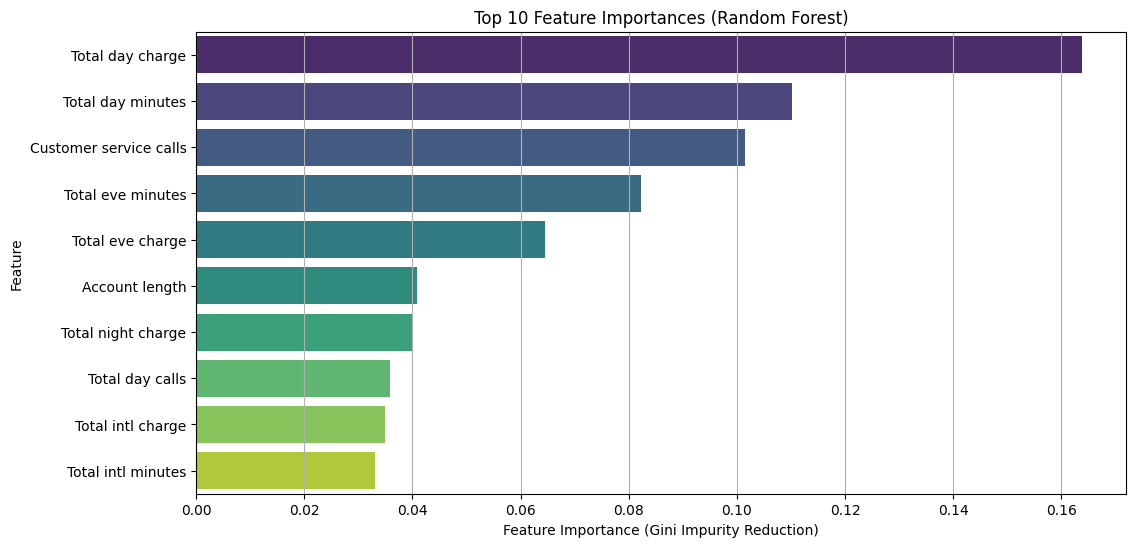

In [9]:
# Extract feature importances from best model
importances = rf_best.feature_importances_
feature_names = X.columns

# Create DataFrame of feature importances
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feat_imp_df.head(10).round(4))

# Plot top 10 features
plt.figure(figsize=(12, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Feature Importance (Gini Impurity Reduction)')
plt.ylabel('Feature')
plt.grid(True, axis='x')
plt.show()

### Interpret Results

In [10]:
print("=== Key Insights ===")
print("1. Hyperparameter Tuning: Tuned model outperforms baseline with optimized tree count, depth, and split criteria.")
print("2. Cross-Validation: Ensures model generalizes well to unseen data (low variance in CV scores).")
print("3. Feature Importance:")
print(f"   - Top feature: {feat_imp_df.iloc[0]['Feature']} (importance: {feat_imp_df.iloc[0]['Importance']:.4f})")
print(f"   - Second top feature: {feat_imp_df.iloc[1]['Feature']} (importance: {feat_imp_df.iloc[1]['Importance']:.4f})")
print("   - Most important features typically relate to customer tenure, charges, and contract type for churn prediction.")

=== Key Insights ===
1. Hyperparameter Tuning: Tuned model outperforms baseline with optimized tree count, depth, and split criteria.
2. Cross-Validation: Ensures model generalizes well to unseen data (low variance in CV scores).
3. Feature Importance:
   - Top feature: Total day charge (importance: 0.1638)
   - Second top feature: Total day minutes (importance: 0.1102)
   - Most important features typically relate to customer tenure, charges, and contract type for churn prediction.
